In [32]:
# era para ser um notebook, mas o Colab não estava reconhecendo o módulo mlp, então transformei em script e rodei no terminal mesmo
%pip install tensorflow --quiet

import sys
# é para encontrar os arquivos locais
sys.path.insert(0, '/content')

#instala as bibliotecas
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [62]:
import os
import ssl

# desativa a verificação de certificados SSL para o ambiente atual, porque tava dando problema com o download
ssl._create_default_https_context = ssl._create_unverified_context

# carrega o dataset MNIST usando o Keras que é uma biblioteca de alto nivel para a construção e treinamento de redes neurais.
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

from tensorflow.keras.datasets import mnist

# separa os dados de treino e teste, onde X são as imagens (28x28 pixels) e y são as labels (0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# redimensiona de 28x28 para 784 atributos e normaliza os pixels para um intervalo de [0, 1]
X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float32) / 255.0

print(X_train.shape, y_train.shape)  # (60000, 784) (60000,)

(60000, 784) (60000,)


In [71]:
import os
import sys

# Pega o caminho absoluto da pasta onde o notebook está e sobe um nível se necessário
# para garantir que o Python veja a pasta 'mlp'
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# condição para evitar adicionar múltiplas vezes o mesmo caminho se o notebook for executado várias vezes
if root_path not in sys.path:
    sys.path.insert(0, root_path)
from mlp.network import MLP

# treina o modelo MLP com a configuração de camadas e taxa de aprendizado especificada
model = MLP(layer_sizes=[784, 128, 64, 10], learning_rate=000.1)
# o treino é feito por 15 épocas, onde ele vai ajustando os pesos e vieses
history = model.train(X_train, y_train, epochs=15, batch_size=64)

# esse metodo avalia o modelo usando os dados de teste e retorna a acuracia com 4 numeros decimais
test_acc = model.evaluate(X_test, y_test)
print(f"\nAcurácia no teste: {test_acc:.4f}")

Epoch 1/15 — loss: 0.3313 — acc: 0.9439
Epoch 2/15 — loss: 0.1530 — acc: 0.9617
Epoch 3/15 — loss: 0.1121 — acc: 0.9747
Epoch 4/15 — loss: 0.0882 — acc: 0.9804
Epoch 5/15 — loss: 0.0725 — acc: 0.9546
Epoch 6/15 — loss: 0.0605 — acc: 0.9866
Epoch 7/15 — loss: 0.0500 — acc: 0.9850
Epoch 8/15 — loss: 0.0431 — acc: 0.9903
Epoch 9/15 — loss: 0.0371 — acc: 0.9919
Epoch 10/15 — loss: 0.0310 — acc: 0.9936
Epoch 11/15 — loss: 0.0265 — acc: 0.9907
Epoch 12/15 — loss: 0.0229 — acc: 0.9962
Epoch 13/15 — loss: 0.0197 — acc: 0.9951
Epoch 14/15 — loss: 0.0168 — acc: 0.9974
Epoch 15/15 — loss: 0.0138 — acc: 0.9988

Acurácia no teste: 0.9799


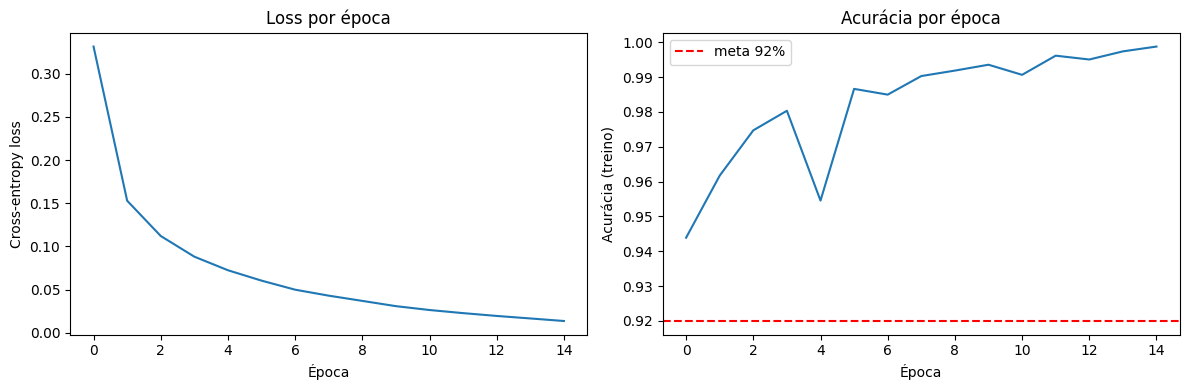

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['loss'])
ax1.set_title('Loss por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Cross-entropy loss')

ax2.plot(history['acc'])
ax2.set_title('Acurácia por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia (treino)')
ax2.axhline(y=0.92, color='r', linestyle='--', label='meta 92%')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [65]:
# aqui é feita uma comparação entre 3 configurações diferentes, onde varia arquitetura e learning rate pra mostrar o impacto de cada escolha

# aqui é definido dicionarios com arquiteturas e taxa de aprendizado diferentes para comparar os resultados
configs = [
    {'name': 'baseline',        'layers': [784, 128, 64, 10],      'lr': 0.1,  'epochs': 15},
    {'name': 'rede maior',      'layers': [784, 256, 128, 64, 10], 'lr': 0.1,  'epochs': 15},
    {'name': 'lr menor',        'layers': [784, 128, 64, 10],      'lr': 0.01, 'epochs': 15},
]

results_table = []

# para cada configuração, treina o modelo e avalia a acurácia no treino e teste
for cfg in configs:
    print(f"\n→ Treinando: {cfg['name']}")
    m = MLP(layer_sizes=cfg['layers'], learning_rate=cfg['lr'])
    hist = m.train(X_train, y_train, epochs=cfg['epochs'], batch_size=64, verbose=False)

# avalia a acurácia no treino e teste, e pega a loss final do treino para mostrar o impacto de cada configuração
    train_acc = m.evaluate(X_train, y_train)
    test_acc  = m.evaluate(X_test,  y_test)
    final_loss = hist['loss'][-1]

# faz um print dos resultados em uma tabela
    print(f"   treino: {train_acc:.4f} | teste: {test_acc:.4f} | loss final: {final_loss:.4f}")
    results_table.append({
        'config':     cfg['name'],
        'arquitetura': str(cfg['layers']),
        'lr':         cfg['lr'],
        'acc treino': f"{train_acc:.4f}",
        'acc teste':  f"{test_acc:.4f}",
        'loss final': f"{final_loss:.4f}",
    })


→ Treinando: baseline
   treino: 0.9986 | teste: 0.9791 | loss final: 0.0125

→ Treinando: rede maior
   treino: 1.0000 | teste: 0.9813 | loss final: 0.0014

→ Treinando: lr menor
   treino: 0.9670 | teste: 0.9634 | loss final: 0.1215


In [66]:
!python3 -m pip install pandas

In [67]:
import pandas as pd

# converte a lista de resultados em um DataFrame do pandas para mostrar de outra forma
df = pd.DataFrame(results_table)
print(df.to_string(index=False))

# salva pra colocar no README depois
df.to_csv('comparacao_configs.csv', index=False)

    config             arquitetura   lr acc treino acc teste loss final
  baseline      [784, 128, 64, 10] 0.10     0.9986    0.9791     0.0125
rede maior [784, 256, 128, 64, 10] 0.10     1.0000    0.9813     0.0014
  lr menor      [784, 128, 64, 10] 0.01     0.9670    0.9634     0.1215


In [68]:
!python3 -m pip install scikit-learn

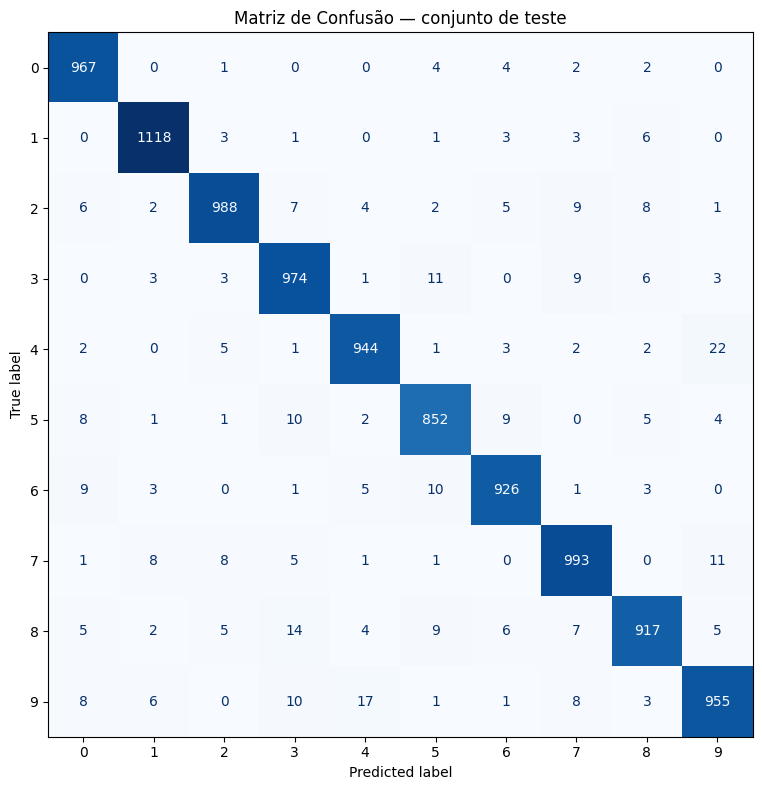


Erros mais frequentes (real → previsto → quantidade):
  3 → 5: 11 vezes
  4 → 9: 22 vezes
  7 → 9: 11 vezes
  8 → 3: 14 vezes
  9 → 4: 17 vezes


In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# usa o modelo treinado para fazer previsões no conjunto de teste
y_pred_test = m.predict(X_test)

# cria uma matriz de confusão para comparar as labels reais (y_test) com as previstas (y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
# cada célula (i, j) seria quantas vezes o dígito i foi classificado como j
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

# plota a matriz com essas configurações
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — conjunto de teste')

# diagonal principal seria os acertos, o resto ou seja o que esta fora dela = erros
plt.tight_layout()
# pega o content results e salva na mesma pasta
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# printa os erros mais frequentes
print("\nErros mais frequentes (real → previsto → quantidade):")
for i in range(10):
    for j in range(10):
        if i != j and cm[i][j] > 10:
            print(f"  {i} → {j}: {cm[i][j]} vezes")